In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
import scipy.stats as scst
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from sklearn.mixture import GaussianMixture
import random
import scipy.stats as stats
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib import cm
from matplotlib.colors import Normalize
import statsmodels.api as sm

ModuleNotFoundError: No module named 'tqdm'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
#from tqdm import tqdm
import seaborn as sns

In [3]:
k = 21
l = 150

Read from 0 to 150
k-mer from 150 to 171
Read from 1 to 151
k-mer from 150 to 171
Read from 2 to 152
k-mer from 150 to 171
Read from 3 to 153
k-mer from 150 to 171
Read from 4 to 154
k-mer from 150 to 171
Read from 5 to 155
k-mer from 150 to 171
Read from 6 to 156
k-mer from 150 to 171
Read from 7 to 157
k-mer from 150 to 171
Read from 8 to 158
k-mer from 150 to 171
Read from 9 to 159
k-mer from 150 to 171
Read from 10 to 160
k-mer from 150 to 171
Read from 11 to 161
k-mer from 150 to 171
Read from 12 to 162
k-mer from 150 to 171
Read from 13 to 163
k-mer from 150 to 171
Read from 14 to 164
k-mer from 150 to 171
Read from 15 to 165
k-mer from 150 to 171
Read from 16 to 166
k-mer from 150 to 171
Read from 17 to 167
k-mer from 150 to 171
Read from 18 to 168
k-mer from 150 to 171
Read from 19 to 169
k-mer from 150 to 171
Read from 20 to 170
k-mer from 150 to 171
Read from 21 to 171
k-mer from 150 to 171
Read from 22 to 172
k-mer from 150 to 171
Read from 23 to 173
k-mer from 150 to 171
Re

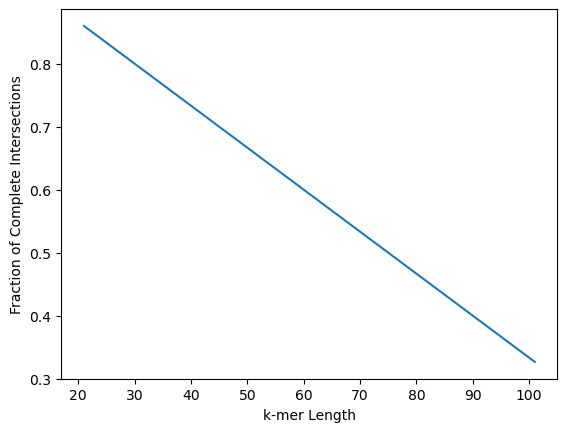

[0.86, 0.7933333333333333, 0.7266666666666667, 0.66, 0.5933333333333334, 0.46, 0.32666666666666666]


In [16]:
x = []
y = []

for kmer_length in [21, 31, 
                   41,
                   51,
                   61,
                   81,
                   101
                  ]:

    num_queries = 0
    num_complete_intersections = 0
    
    for offset in range(0, l):
        read_start = 0 + offset
        read_end = 0 + offset + l
        print(f"Read from {read_start} to {read_end}")
        
        k = kmer_length
        kmer_start = l
        kmer_end = l + k
        print(f"k-mer from {kmer_start} to {kmer_end}")
        
        intersection = max(read_start, kmer_start), min(read_end, kmer_end)
        #print(f"Intersection from {intersection[0]} to {intersection[1]} for {intersection[1] - intersection[0]}")

        num_queries += 1
        if intersection[1] - intersection[0] == k:
            num_complete_intersections += 1

    x.append(kmer_length)
    y.append(num_complete_intersections / num_queries)

plt.plot(x, y)
plt.xlabel("k-mer Length")
plt.ylabel("Fraction of Complete Intersections")
plt.show()
print(y)

# Extracts position of the CDR in centromeres

This is based on the data from Gao et al., 2026, Nature, A global view of human centromere variation and evolution

I downloaded the data bundle from `https://doi.org/10.6084/m9.figshare.29921990`

In [3]:
chromosomes = [f"chr{i}" for i in range(1, 23)]

### load cdr location and hor annoations

In [4]:
cdr_df = pd.read_csv(
    "/home/hain/EMBL/Centromere_project/revision/data/29921990/Centromere sequences annotation of HGSVC3, CHM1 and CHM13/centromere dip region annotation.bed",
    sep="\t",
    header=None,
    names=["cent_cutout", "cdr_start", "cdr_end"]
)
cdr_df["cdr_mean"] = (cdr_df["cdr_start"] + cdr_df["cdr_end"]) / 2
cdr_df.head()

,cent_cutout,cdr_start,cdr_end,cdr_mean
0,chm13_chr10:38568472-42561808,39993472,40058470,40025971.0
1,chm13_chr10:38568472-42561808,40058472,40123472,40090972.0
2,chm13_chr10:38568472-42561808,40123474,40178472,40150973.0
3,chm13_chr1:121119216-127324115,122674216,122759214,122716715.0
4,chm13_chr1:121119216-127324115,122759216,122794216,122776716.0


In [5]:
### add chromosome column
col_chrom = []
for idx, row in cdr_df.iterrows():
    cent_cutout = row["cent_cutout"]
    chrom = "NA"
    for s1 in row["cent_cutout"].split("_"):
        for s2 in s1.split(":"):
            if s2.startswith("chr"):
                chrom = s2
                break
    col_chrom.append(chrom)

cdr_df["chrom"] = col_chrom

In [6]:
hor_df_chrom = []
for chrom in tqdm(chromosomes, total=len(chromosomes), desc="Loading HOR annotation files"):
    hor_df_chrom.append(
        pd.read_csv(
            f"/home/hain/EMBL/Centromere_project/revision/data/29921990/Centromere sequences annotation of HGSVC3, CHM1 and CHM13/alpha satellite higher order repeat annotation/{chrom}_AS-HOR_stv_row.all.bed",
            sep="\t",
            header=None,
            names=["cent_cutout", "hor_start", "hor_end", "hor_name", "score", "strand", "tstart", "tend", "color"]
        )
    )
hor_df = pd.concat(hor_df_chrom, ignore_index=True).reset_index(drop=True).sort_values(by=["cent_cutout", "hor_start"]).reset_index(drop=True)
hor_df["hor_length"] = hor_df["hor_end"] - hor_df["hor_start"]
hor_df

Loading HOR annotation files: 100%|██████████| 22/22 [00:03<00:00,  5.72it/s]


,cent_cutout,hor_start,hor_end,hor_name,score,strand,tstart,tend,color,hor_length
0,HG00096_chr10_haplotype2-0000118:38552782-4215...,39589884,39590223,S1C10H1L.2_7/5,0,+,39589884,39590223,"0,0,0",339
1,HG00096_chr10_haplotype2-0000118:38552782-4215...,39590224,39590563,S1C10H1L.2_5,0,+,39590224,39590563,"0,0,0",339
2,HG00096_chr10_haplotype2-0000118:38552782-4215...,39590564,39590903,S1C10H1L.2_5,0,+,39590564,39590903,"0,0,0",339
3,HG00096_chr10_haplotype2-0000118:38552782-4215...,39590904,39591243,S1C10H1L.2_5,0,+,39590904,39591243,"0,0,0",339
4,HG00096_chr10_haplotype2-0000118:38552782-4215...,39591244,39591583,S1C10H1L.2_5,0,+,39591244,39591583,"0,0,0",339
...,...,...,...,...,...,...,...,...,...,...
6503199,chm1_chr9:44537770-48088919,47578865,47580054,S2C9H1L.1-7,0,+,47578865,47580054,"0,0,0",1189
6503200,chm1_chr9:44537770-48088919,47580055,47580904,S2C9H1L.1-4_5/1,0,+,47580055,47580904,"0,0,0",849
6503201,chm1_chr9:44537770-48088919,47582948,47583118,S2C9H1L.7,0,+,47582948,47583118,"0,0,0",170
6503202,chm1_chr9:44537770-48088919,47583119,47583456,S2C9H1L.1-2,0,+,47583119,47583456,"0,0,0",337


In [7]:
### get relative position of the CDR
"""
For this I want to iterate over each individual haplotype and calculate the relative position of its CDR(s). For this I will 
    - (b) query them from left to right,
    - (c) check after how many HOR bases I find the repeat unit that contains the CDR (just use the start position)
    - (d) calculate the relative CDR position based on the queried bases until the CDR position divided by the total number of HOR bases
"""

rel_cdr_data = []

for hp, hp_hor_df in tqdm(hor_df[hor_df["hor_name"].str.contains("L.")].groupby("cent_cutout"), total=hor_df["cent_cutout"].nunique(), desc="Processing haplotypes"):

    # find CDR(s) for this hp
    cdr_positions = cdr_df[cdr_df["cent_cutout"] == hp]["cdr_mean"].tolist()
    # find chromosome for this hp
    chrom = cdr_df[cdr_df["cent_cutout"] == hp]["chrom"].tolist()[0]

    # iterate over the CDRs
    for cdr_pos in cdr_positions:
        # prepare number of HOR bases
        total_hor_bases = hp_hor_df["hor_length"].sum()
        queried_hor_bases = 0
        # iterate over the HORs for this hp
        for idx, row in hp_hor_df.iterrows():
            queried_hor_bases += row["hor_length"]
            if cdr_pos <= row["hor_start"]:
                # found the HOR that contains the CDR
                break
        rel_cdr_data.append({"chromosome":chrom, "cent_cutout":hp, "cdr_mean":cdr_pos, "rel_cdr_position":queried_hor_bases / total_hor_bases})
            
rel_cdr_df = pd.DataFrame(rel_cdr_data)

Processing haplotypes: 100%|██████████| 2058/2058 [02:50<00:00, 12.07it/s]


### add cluster information

In [8]:
### add sample and haplotype columns
col_hp = []
col_sample = []
for idx, row in rel_cdr_df.iterrows():
    cent_cutout = row["cent_cutout"]
    sample = cent_cutout.split("_")[0]
    if "haplotype1" in cent_cutout:
        hp = "HP1"
    elif "haplotype2" in cent_cutout:
        hp = "HP2"
    else:
        hp = "NA"
    col_hp.append(hp)
    col_sample.append(sample)
rel_cdr_df["haplotype"] = col_hp
rel_cdr_df["sample"] = col_sample

In [9]:
samplesheet = pd.read_csv("/home/hain/EMBL/Centromere_project/samplesheet/centromeres_full.active.length.cluster.tsv", sep="\t")
samplesheet.head()

,SAMPLE,ASM,HP,PROJECT,CHROM,CENT_FASTA_PATH,NUM_CONTIGS,CONTIG_LENGTH,FAMILY,FAMILYSTATE,SUPERPOP,POP,ID,ACTIVE,UNSTABLE,HOR_LENGTH,HOR_SPAN,ARCHITECTURE
0,CHM1,T2T,HP1,T2T,chr21,/scratch/hain/centromere/centromeres/chr21_CHM...,1,1819674,NaN,NaN,EAS,NaN,CHM1_HP1_T2T_T2T,True,False,1176502,1228355,chr21_968
1,HG04204,HPRC,HP2,HPRC2,chr3,/scratch/hain/centromere/centromeres/chr3_HG04...,1,5273549,ST006,child,SAS,STU,HG04204_HP2_HPRC_HPRC2,True,False,2140104,4006938,chr3_1009
2,HG03704,HPRC,HP2,HPRC2,chr2,/scratch/hain/centromere/centromeres/chr2_HG03...,1,4968267,PK60,child,SAS,PJL,HG03704_HP2_HPRC_HPRC2,True,False,2180995,2214651,chr2_929
3,HG00731,VERKKO,HP2,HGSVC,chr20,/scratch/hain/centromere/centromeres/chr20_HG0...,1,7316426,PR05,father,AMR,PUR,HG00731_HP2_VERKKO_HGSVC,True,False,2445974,5672092,chr20_1081
4,HG03369,HPRC,HP2,HPRC2,chr4,/scratch/hain/centromere/centromeres/chr4_HG03...,1,4918950,NG98,mother,AFR,ESN,HG03369_HP2_HPRC_HPRC2,True,False,3413929,3677878,chr4_1075


In [10]:
col_cluster = []

for idx, row in rel_cdr_df.iterrows():
    sample = row["sample"]
    cluster_df = samplesheet[
        (samplesheet["SAMPLE"] == sample) &
        (samplesheet["HP"] == row["haplotype"]) &
        (samplesheet["CHROM"] == row["chromosome"])
    ]["ARCHITECTURE"]
    if cluster_df.empty:
        cluster = "NA"
    else:
        cluster = cluster_df.tolist()[0]
    col_cluster.append(cluster)
rel_cdr_df["cluster"] = col_cluster

(0.0, 1.0)

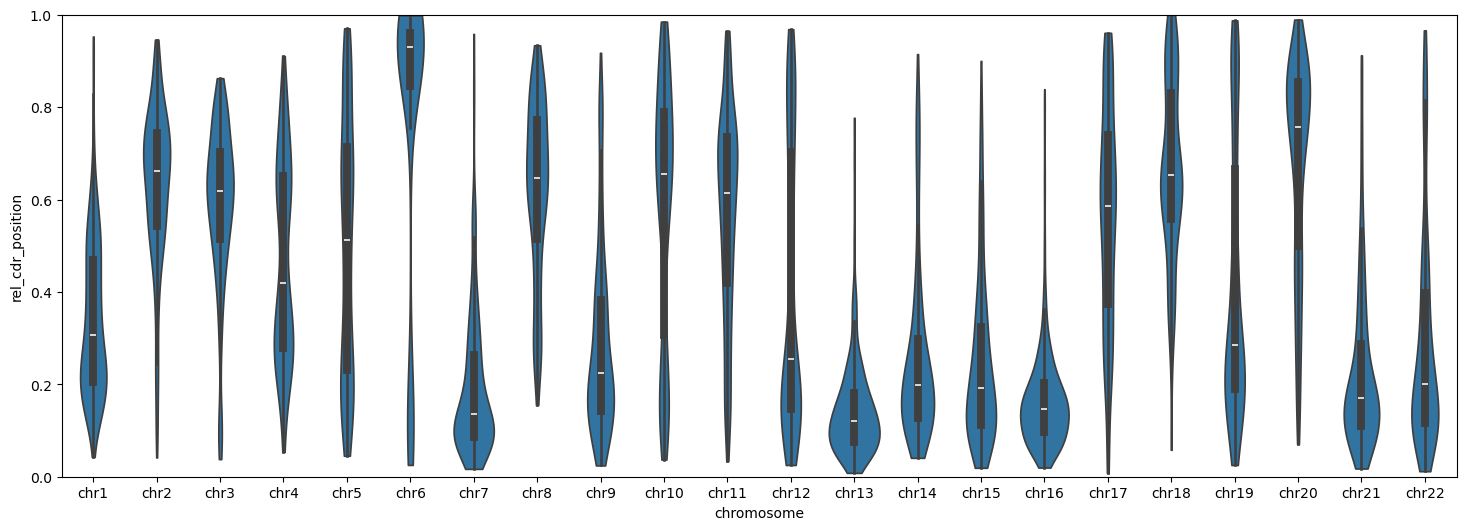

In [11]:
fig, ax = plt.subplots(figsize=(18, 6))
sns.violinplot(x="chromosome", y="rel_cdr_position", data=rel_cdr_df, order=chromosomes, ax=ax, cut=0)
ax.set_ylim(0, 1)

/tmp/ipykernel_30332/981104399.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_30332/981104399.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_30332/981104399.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_30332/981104399.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_30332/981104399.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_30332/9811

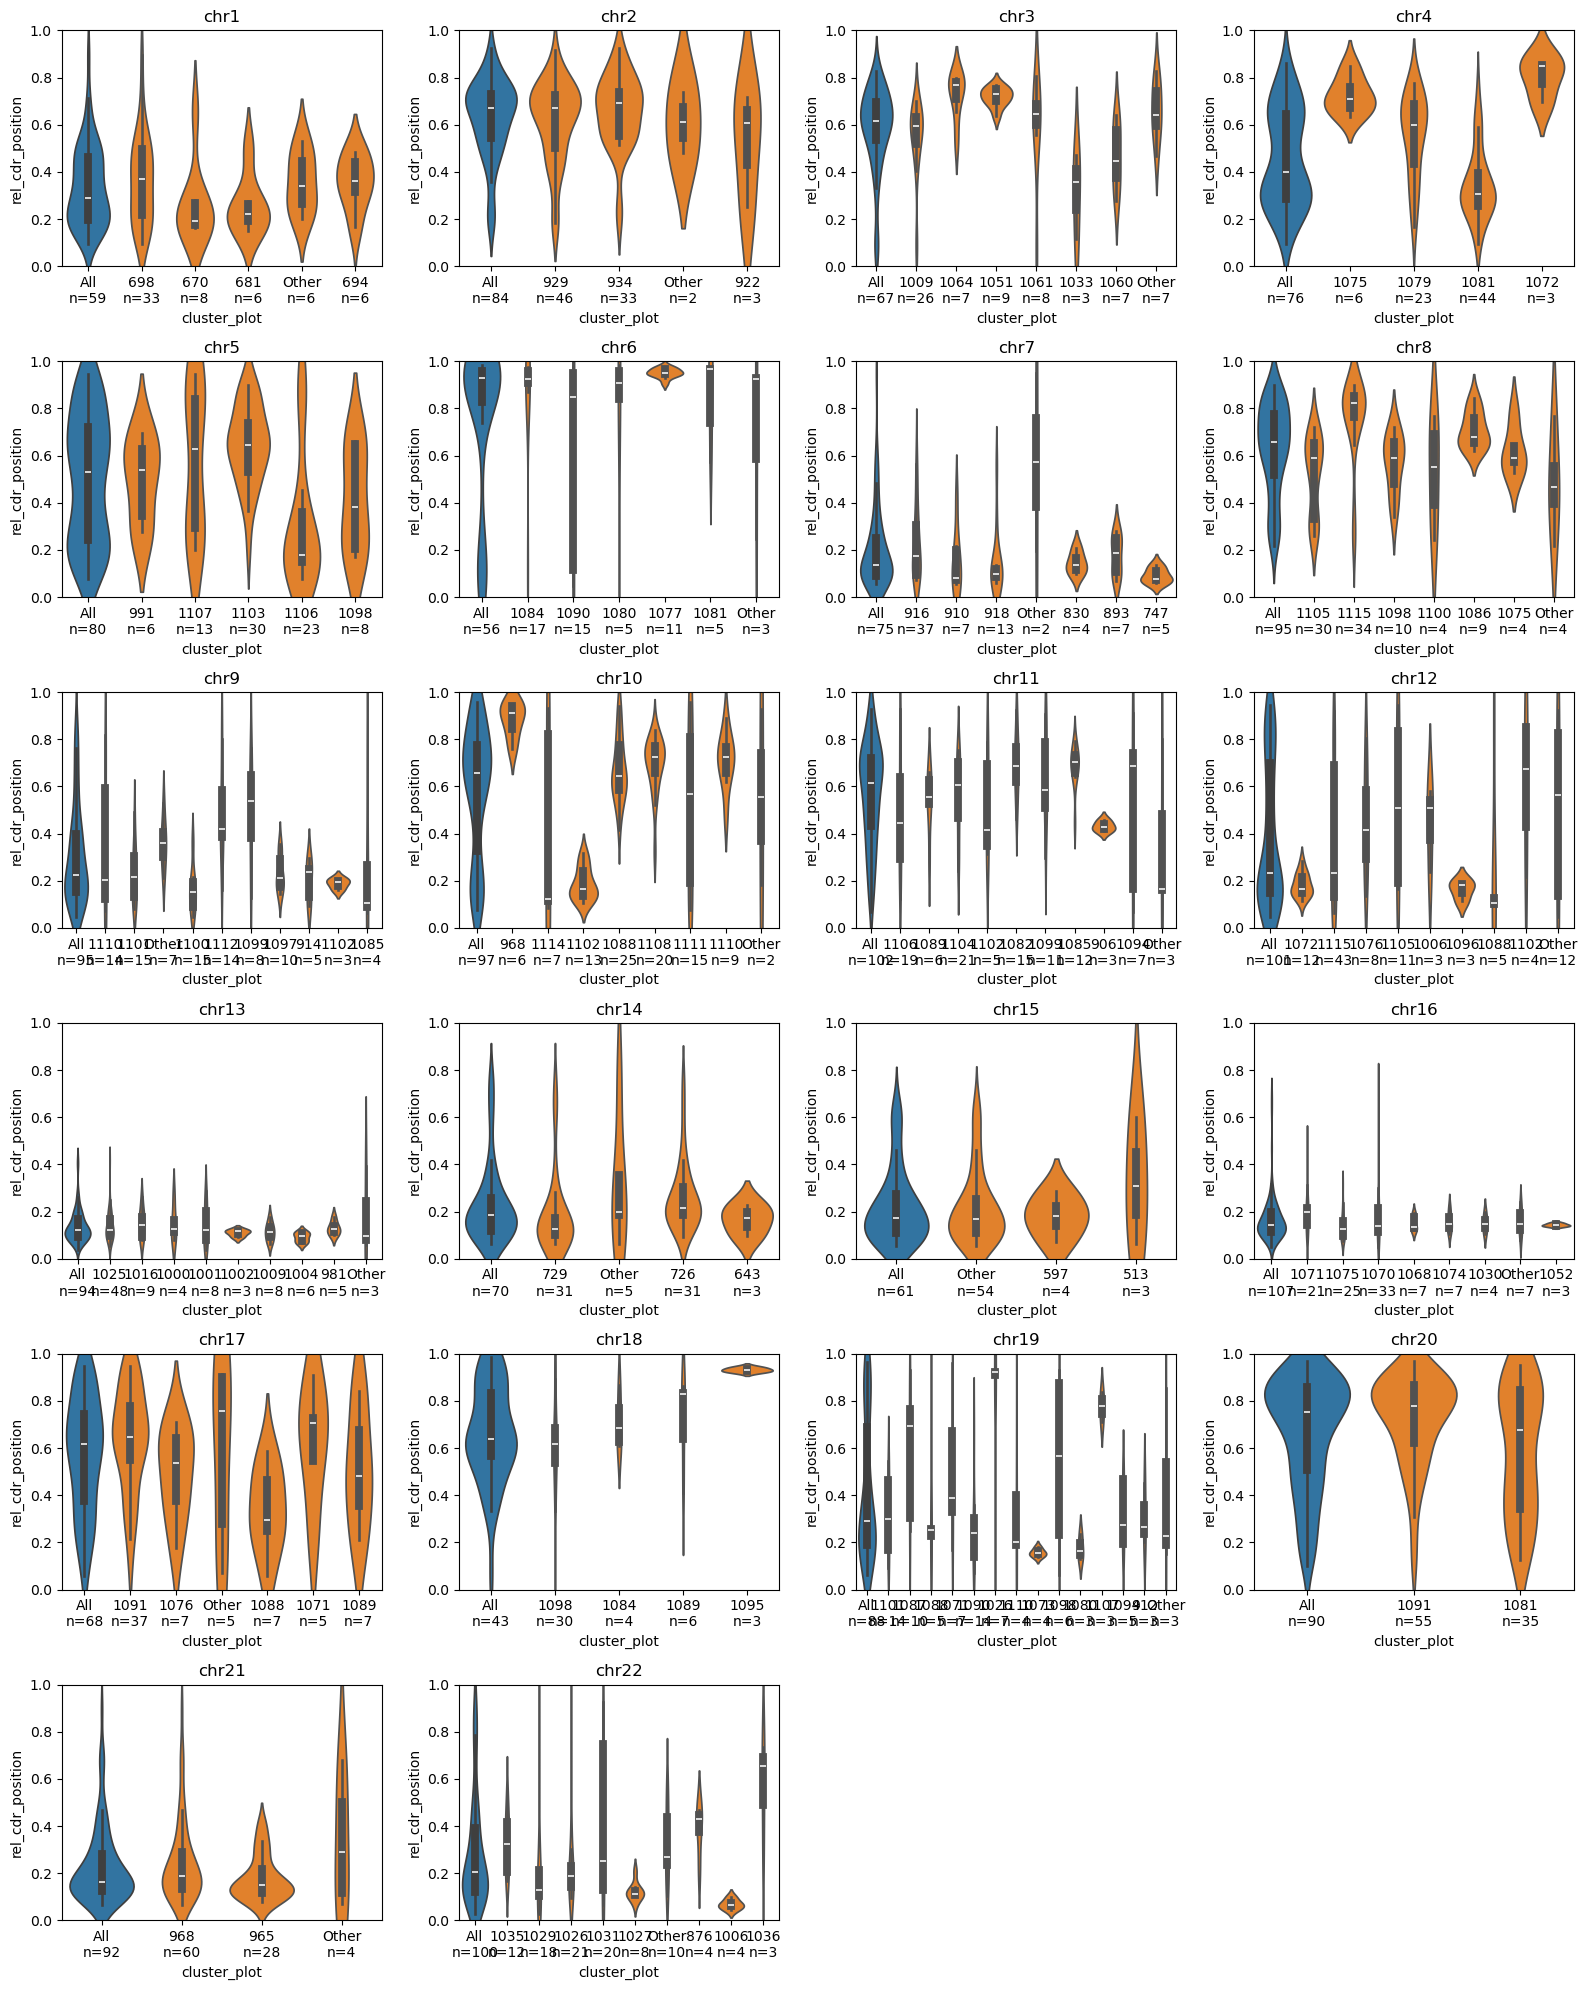

In [14]:
for k, chrom in enumerate(chromosomes):
    
    ### merge cdrs
    # collapse duplicated cent_cutout entries by averaging rel_cdr_position
    plot_df = (
        rel_cdr_df[(rel_cdr_df["chromosome"] == chrom) & (rel_cdr_df["cluster"] != "NA")]
        .groupby("cent_cutout", as_index=False)
        .agg(
            chromosome=("chromosome", "first"),
            haplotype=("haplotype", "first"),
            sample=("sample", "first"),
            cluster=("cluster", "first"),
            rel_cdr_position=("rel_cdr_position", "mean"),
            n_rows_merged=("rel_cdr_position", "size")
        )
    )

    col_updated_cluster = []
    for idx, row in plot_df.iterrows():
        if plot_df[plot_df["cluster"] == row["cluster"]].shape[0] < 3:
            col_updated_cluster.append("Other")
        else:
            col_updated_cluster.append(row["cluster"].split("_")[1] + "\nn=" + str(plot_df[plot_df["cluster"] == row["cluster"]].shape[0]))
    plot_df["cluster_plot"] = col_updated_cluster
    n_other = plot_df[plot_df["cluster_plot"] == "Other"].shape[0]
    plot_df["cluster_plot"] = plot_df["cluster_plot"].replace("Other", f"Other\nn={n_other}")
    
    ax = plt.subplot(6, 4, k + 1)
    ax.set_title(chrom)
    sns.violinplot(
        plot_df,
        y="rel_cdr_position",
        ax=ax
    )
    sns.violinplot(
        plot_df,
        x="cluster_plot",
        y="rel_cdr_position",
        ax=ax
    )
    
    labels = ax.get_xticklabels()
    labels[0] = f"All\nn={plot_df.shape[0]}"
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)

plt.gcf().set_size_inches(16, 20)
plt.tight_layout()
plt.show()
plt.close()